# Parkinson's Disease Classifier
**ML Final Project**
***University of Padova***

Group 4:
- Larissa Pereira Moraes
- Zainab Fatima
- Yousra Dehgane

***

## Section 1: The Biological Problem

The question we are dealing with in this project is where we can classify a healthy patient from a patient with Parkinson's disease based on the voice biomarkers.

The following are the factors we are utilizing from our dataset to build the model:
- Input data: voice measurements
- Target variable: status 0 (healthy) and 1 (Parkinson's)
- One row represents: a voice recording
- One column represents: a feature

**Biological relevance:** Parkison's disease presents vocal alterations in the early to mid stages of the disease, making it a possible factor to detect using a machine learning model as a low-cost diagnostic method (Xiu et al., 2024).

## Environment Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from ucimlrepo import fetch_ucirepo as fetch_uci_dataset

# import sys
# !{sys.executable} -m pip install ucimlrepo

np.random.seed(42)

### Section 2: Exploratory Data Analysis

Point 2.1
Report the number of samples and the number of variables.

Point 2.2
Identify which columns are metadata, which columns are input features, and which column is the target.


## Section 4: Defining X and y
Point 4.1
Print the shape of X and explain what the two dimensions mean.

Point 4.2
Print the shape of y and explain what each element represents.

Point 4.3
If your dataset is a biological count or expression matrix, state whether you had to transpose it.

Point 4.4
Explain why the same dataset could lead to different Machine Learning (ML) tasks depending on the chosen target.


In [2]:
# Dataset 5 - Parkinsons

parkinson = fetch_uci_dataset(id=174) # fetched data from UCI API

X_parkinson_raw = parkinson.data.features.copy()  # copy of all the features
y_parkinson_raw = parkinson.data.targets.copy()   # copy of all the samples' targets

# printing features and targets
print("Feature columns:")
print(X_parkinson_raw.columns.tolist())

print("\nTarget columns:")
print(y_parkinson_raw.columns.tolist())

# getting the target column as a 1D array to be used in sklearn
# iloc[:, 0] flattens the 2D array into a 1D series for sklearn's fit(X,y)
y_parkinson = y_parkinson_raw.iloc[:, 0].copy()

# Remove non-numeric if present: column "name" 
X_parkinson = X_parkinson_raw.select_dtypes(include="number").copy()

# compiling the X and y into a new Panda's dataframe
parkinson_data = pd.concat(
    [X_parkinson, pd.Series(y_parkinson, name="target")],
    axis=1
)

print("X shape:", X_parkinson.shape)
print("y shape:", y_parkinson.shape)
print("Target values:")
print(pd.Series(y_parkinson).value_counts())

parkinson_data.head()

Feature columns:
['MDVP:Fo', 'MDVP:Fhi', 'MDVP:Flo', 'MDVP:Jitter', 'MDVP:Jitter', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']

Target columns:
['status']
X shape: (195, 22)
y shape: (195,)
Target values:
status
1    147
0     48
Name: count, dtype: int64


,MDVP:Fo,MDVP:Fhi,MDVP:Flo,MDVP:Jitter,MDVP:Jitter,MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,target
0,119.992,157.302,74.997,0.00784,0.00784,0.00370,0.00554,0.01109,0.04374,0.04374,...,0.06545,0.02211,21.033,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654,1
1,122.400,148.650,113.819,0.00968,0.00968,0.00465,0.00696,0.01394,0.06134,0.06134,...,0.09403,0.01929,19.085,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674,1
2,116.682,131.111,111.555,0.01050,0.01050,0.00544,0.00781,0.01633,0.05233,0.05233,...,0.08270,0.01309,20.651,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634,1
3,116.676,137.871,111.366,0.00997,0.00997,0.00502,0.00698,0.01505,0.05492,0.05492,...,0.08771,0.01353,20.644,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975,1
4,116.014,141.781,110.655,0.01284,0.01284,0.00655,0.00908,0.01966,0.06425,0.06425,...,0.10470,0.01767,19.649,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335,1


In [3]:
parkinson.variables

,name,role,type,demographic,description,units,missing_values
0,name,ID,Categorical,None,None,None,no
1,MDVP:Fo,Feature,Continuous,None,None,Hz,no
2,MDVP:Fhi,Feature,Continuous,None,None,Hz,no
3,MDVP:Flo,Feature,Continuous,None,None,Hz,no
4,MDVP:Jitter,Feature,Continuous,None,None,%,no
5,MDVP:Jitter,Feature,Continuous,None,None,Abs,no
6,MDVP:RAP,Feature,Continuous,None,None,None,no
7,MDVP:PPQ,Feature,Continuous,None,None,None,no
8,Jitter:DDP,Feature,Continuous,None,None,None,no
9,MDVP:Shimmer,Feature,Continuous,None,None,None,no


## Section 3: Determining the Machine Learning Task

Target type:

Problem type:

Compatible models:

Models that are not appropriate and why:


## Section 5: Dataset audit

Point 5.1
Is your dataset small, medium, or large relative to the number of features?

Point 5.2
If this is a classification task, are the classes balanced?

Point 5.3
Do the features need scaling? Justify your answer based on the models you plan to use.

Point 5.4
Identify one possible risk in this dataset, such as overfitting, class imbalance, outliers, or leakage.

### Column Duplicate Check 

The UCI dataset loaded via the API contains duplicated column labels for MDVP:Jitter and MDVP:Shimmer.

Although the dataset documentation defines 22 distinct features, two feature pairs appear under identical names in the loaded DataFrame.

Comparing our dataset with the same dataset available on Kaggle (see Supplementary Material), we observed that the feature definitions are consistent across sources. However, in the UCI API-loaded version used in this analysis, two feature pairs (MDVP:Jitter(%);MDVP:Jitter(abs) and MDVP:Shimmer;MDVP:Shiimer(db))) appear as duplicated columns with identical values. 

In [4]:
# verifying which columns are duplicates
print(X_parkinson.columns[X_parkinson.columns.duplicated()])

Index(['MDVP:Jitter', 'MDVP:Shimmer'], dtype='object')


**Verifying MDVP:Jitter**

In [5]:
# check if column is duplicate
X_parkinson.iloc[:, 3].head()   # first MDVP:Jitter

0    0.00784
1    0.00968
2    0.01050
3    0.00997
4    0.01284
Name: MDVP:Jitter, dtype: float64

In [6]:
(X_parkinson.iloc[:, 3] == X_parkinson.iloc[:, 4]).all()

np.True_

In [7]:
jitter_cols = X_parkinson.loc[:, "MDVP:Jitter"]

# print(jitter_cols.head())
print((jitter_cols.iloc[:, 0] == jitter_cols.iloc[:, 1]).all())

True


**Verifying MDVP:Shimmer**

In [8]:
shimmer_cols = X_parkinson.loc[:, "MDVP:Shimmer"]

# print(jitter_cols.head())
print((shimmer_cols.iloc[:, 0] == shimmer_cols.iloc[:, 1]).all())

True


**Dropping Duplicate Columns**

Duplicate features were removed because they provide no additional information and may bias some models or inflate feature importance.

In [9]:
# Dropping duplicate columns
X_parkinson_clean = X_parkinson.T.drop_duplicates().T
X_parkinson_clean.shape

(195, 20)

In [10]:
# sanity check for duplicates
print(X_parkinson_clean.columns[X_parkinson_clean.columns.duplicated()])

Index([], dtype='object')


### Missing Values Check

In [11]:
# add code here

### Class Balance Check

Due to class imbalance, model evaluation will prioritize recall and F1-score over accuracy, as false negatives (failing to detect Parkinson’s disease) are clinically more critical than false positives.

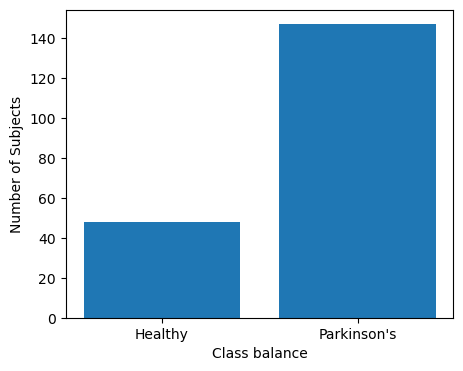

In [12]:
# Class Balance
labels = ["Healthy", "Parkinson's"]
counts = [np.sum(y_parkinson == 0), np.sum(y_parkinson == 1)]

plt.figure(figsize=(5, 4))
plt.bar(labels, counts)
plt.ylabel("Number of Subjects")
plt.xlabel("Class balance")
plt.show()

**Visualize Distribution of Features**

Visual inspection of feature distributions shows that HNR provides strong separation between classes, with healthy subjects exhibiting higher values. RPDE and DFA show partial but less distinct separation, suggesting they contribute to classification in combination with other features rather than individually.

In [13]:
parkinson_data["status"] = y_parkinson

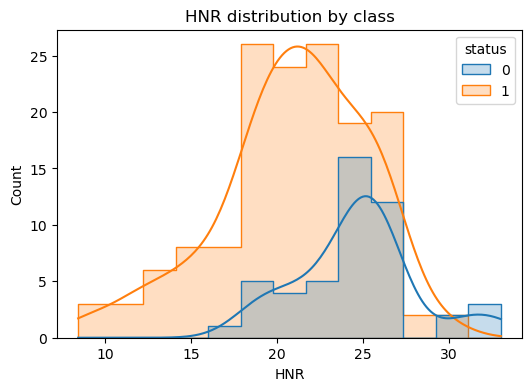

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(data=parkinson_data, x="HNR", hue="status", kde=True, element="step")
plt.title("HNR distribution by class")
plt.show()

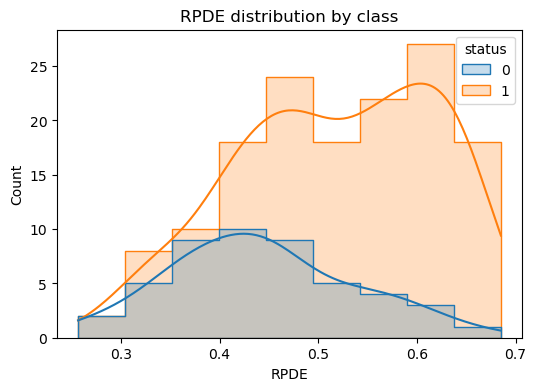

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(data=parkinson_data, x="RPDE", hue="status", kde=True, element="step")
plt.title("RPDE distribution by class")
plt.show()

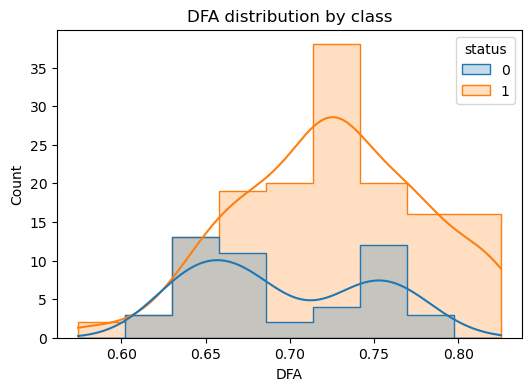

In [16]:
plt.figure(figsize=(6,4))
sns.histplot(data=parkinson_data, x="DFA", hue="status", kde=True, element="step")
plt.title("DFA distribution by class")
plt.show()

In [17]:
# sns.pairplot(parkinson_data[["HNR", "RPDE", "DFA", "status"]], hue="status")

## Section 6: Baseline Model Selection

Point 6.1
Choose the simplest reasonable baseline for your task.

Point 6.2
Explain why this baseline is appropriate.

Point 6.3
Evaluate the baseline on the validation set.

Point 6.4
State what performance a more complex model must beat to be useful.

## Section 7: Candidate Models

Baseline model: Logistic Regression

Logistic Regression is the baseline model because this is a binary classification task. The target variable is `status`, where 0 represents healthy subjects and 1 represents Parkinson's disease. Logistic Regression is simple, fast, and interpretable, so it gives us a clear reference point before testing more complex models.

Candidate model 1: Random Forest Classifier

Why this model:
Random Forest is suitable because it can capture non-linear relationships between the voice features and Parkinson's disease status. This is useful because biomedical voice measurements may interact in complex ways.

Expected advantage:
It does not require feature scaling and can model non-linear patterns. It also provides feature importance, which can help interpret which voice measurements are useful for classification.

Expected risk:
Random Forest can overfit, especially because the dataset is small. If the trees are too deep, the model may memorize the training data instead of generalizing well.

Candidate model 2: Support Vector Machine

Why this model:
Support Vector Machine is useful for small biomedical datasets because it tries to find a strong decision boundary between classes. Using an RBF kernel allows the model to capture non-linear separation between healthy and Parkinson's samples.

Expected advantage:
It can perform well on small datasets and can create non-linear decision boundaries.

Expected risk:
It requires feature scaling and is less interpretable than Logistic Regression. Its performance also depends strongly on hyperparameters such as `C` and `gamma`.

Candidate model 3, optional: K-Nearest Neighbors

Why this model:
KNN is a simple distance-based model that classifies a sample based on the labels of its nearest neighbors. It is useful as an additional comparison model.

Expected advantage:
It is simple and intuitive. It can work well if similar voice profiles belong to the same class.

Expected risk:
It requires feature scaling and may perform poorly when there are many features or noisy measurements. It can also be sensitive to the value of `n_neighbors`.

Reflection points for Section 7

Point 7.1
For each candidate model, state whether feature scaling is required or recommended.

Logistic Regression:
Feature scaling is required/recommended because the model uses coefficients and optimization. Features with larger numerical ranges can dominate the model if scaling is not applied.

Random Forest:
Feature scaling is not required because tree-based models split features using thresholds. The scale of the feature does not affect how the tree makes splits.

Support Vector Machine:
Feature scaling is required because SVM is distance-based. If features are on different scales, the model may give too much importance to features with larger values.

K-Nearest Neighbors:
Feature scaling is required because KNN uses distances between samples. Without scaling, features with larger numeric ranges would dominate the distance calculation.

Point 7.2
For each candidate model, state one important hyperparameter.

Logistic Regression:
An important hyperparameter is `C`, which controls regularization strength. Smaller values of `C` apply stronger regularization.

Random Forest:
An important hyperparameter is `max_depth`, which controls how deep each tree can grow. Deeper trees can fit the training data more closely but may overfit.

Support Vector Machine:
An important hyperparameter is `C`, which controls the trade-off between a wider margin and classification errors. Another important hyperparameter for the RBF kernel is `gamma`.

K-Nearest Neighbors:
An important hyperparameter is `n_neighbors`, which controls how many nearby samples are used to classify a new sample.

Point 7.3
Rank your models from most interpretable to least interpretable.

1. Logistic Regression
2. K-Nearest Neighbors
3. Random Forest
4. Support Vector Machine with RBF kernel

Logistic Regression is the most interpretable because each feature has a coefficient. KNN is simple to understand but does not produce a clear formula. Random Forest can provide feature importance, but the full model is harder to interpret. SVM with RBF kernel is the least interpretable because the decision boundary is complex.

Point 7.4
Which model do you expect to overfit most easily? Why?

Random Forest is expected to overfit most easily if the trees are allowed to become too deep. This is because each tree can learn very specific patterns from the training data, especially in a small dataset. SVM with an RBF kernel can also overfit if `C` or `gamma` are not well controlled. Logistic Regression is less likely to overfit because it is simpler, but it may underfit if the real relationship between the voice features and Parkinson's disease is non-linear.


### Section 8: Train, Validation, and Test Strategy

Point 8.1
Create a train, validation, and test split.

Point 8.2
Report the number of samples in each split.

Point 8.3
If classification, report class balance in each split.

Point 8.4
Explain why the test set should not be used to choose the model.

In [18]:
# Section 8 - Train, validation, and test split template

# For classification, use stratify=y.
X_train_full, X_test, y_train_full, y_test = train_test_split(
     X_parkinson_clean,
     y_parkinson,
     test_size=0.20,
     random_state=42,
     stratify=y_parkinson
 )

X_train, X_val, y_train, y_val = train_test_split(
     X_train_full,
     y_train_full,
     test_size=0.25,  
     random_state=42,
     stratify=y_train_full
 )

# Shape for test, validation, and training sets
print(f"X_train_full shape: {X_train_full.shape}")
print(f"X_test_full shape: {X_test.shape}")
print(f"Training class counts: {np.unique(y_train, return_counts=True)}")
print(f"Test class counts: {np.unique(y_test, return_counts=True)}")

X_train_full shape: (156, 20)
X_test_full shape: (39, 20)
Training class counts: (array([0, 1]), array([28, 89]))
Test class counts: (array([0, 1]), array([10, 29]))


**Feature Scaling**

In [19]:
# scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(class_weight="balanced", max_iter=1000)
model.fit(X_train_scaled, y_train)

train_pred = model.predict(X_train_scaled)
val_pred = model.predict(X_val_scaled)

In [20]:
# Comparing with unbalanced dataset
model_unbalanced = LogisticRegression(max_iter=1000)
model_unbalanced.fit(X_train_scaled, y_train)
y_pred_unbalanced = model_unbalanced.predict(X_val_scaled)

### Section 9: Comparing Models: Logistic Regression vs. Random Forest

Primary metric:

Secondary metrics:

Why these metrics are appropriate:

Which error is more biologically problematic, false positives or false negatives?

Why:

In [21]:
# Section 10 - Model comparison

model_results = []

model_results.append({
    "model": "Logistic Regression (baseline)",
    "train_score": f1_score(y_train, train_pred),
    "validation_score": f1_score(y_val, val_pred),
    "main_metric": f1_score(y_val, val_pred),
    "notes": "Scaled + class_weight=balanced"
})

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    max_depth=5
)

rf.fit(X_train, y_train)

train_pred_rf = rf.predict(X_train)
val_pred_rf = rf.predict(X_val)

model_results.append({
    "model": "Random Forest",
    "train_score": f1_score(y_train, train_pred_rf),
    "validation_score": f1_score(y_val, val_pred_rf),
    "main_metric": f1_score(y_val, val_pred_rf),
    "notes": "No scaling needed, tree-based model"
})

In [23]:
results_df = pd.DataFrame(model_results)
results_df

,model,train_score,validation_score,main_metric,notes
0,Logistic Regression (baseline),0.886228,0.892857,0.892857,Scaled + class_weight=balanced
1,Random Forest,1.000000,0.915254,0.915254,"No scaling needed, tree-based model"


## Section 10: Train and compare models

Point 10.1
Train the baseline model and at least one alternative model.

Point 10.2
Create a summary table of model performance.

Point 10.3
Identify which model performs best on validation data.

Point 10.4
State whether the best model is also the most interpretable model.


In [24]:
# code here

## Section 11: Diagnostic Plots and Learning Curves

Point 11.1
Generate at least one diagnostic plot appropriate for your task.

Point 11.2
State whether your model shows signs of high bias, high variance, or neither.

Point 11.3
Propose one change you would try next based on the diagnostic plot.

Point 11.4
Explain why validation performance is more informative than training performance for model choice.

In [25]:
# code here

## Section 12

## Section 13